In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = mnist.load_data()

# Scale pixel values to 0-1 range
X_train_cnn = X_train_raw.astype('float32') / 255.0
X_test_cnn = X_test_raw.astype('float32') / 255.0

# Add channel dimension (28x28x1) required by 2D Convolution layers
X_train_cnn = np.expand_dims(X_train_cnn, -1)
X_test_cnn = np.expand_dims(X_test_cnn, -1)

# One-hot encode classification targets
y_train_cnn = to_categorical(y_train_raw, 10)
y_test_cnn = to_categorical(y_test_raw, 10)

print("MNIST Image Dataset loaded successfully.")
print(f"  Training features shape: {X_train_cnn.shape} | Test features shape: {X_test_cnn.shape}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST Image Dataset loaded successfully.
  Training features shape: (60000, 28, 28, 1) | Test features shape: (10000, 28, 28, 1)


In [ ]:
from tensorflow.keras.models import Sequential

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Design sequential 2D CNN
cnn_model = Sequential([
    # Convolution layer 1: extracts 32 continuous spatial feature maps
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)), # Downsampling dimension reduction

    # Convolution layer 2: extracts 64 feature maps
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    Flatten(), # Flatten 2D feature grids to 1D vector

    # Dense classification layers with Dropout regularization
    Dense(128, activation='relu'),
    Dropout(0.25),
    Dense(10, activation='softmax') # Softmax activation for multi-class probability outputs
])

print("CNN Architecture successfully established:")
cnn_model.summary()


CNN Architecture successfully established:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("CNN model compiled successfully with Adam optimizer.")

CNN model compiled successfully with Adam optimizer.


In [ ]:

history_cnn = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=5,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

print("\nCNN training complete.")

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 48ms/step - accuracy: 0.9371 - loss: 0.2047 - val_accuracy: 0.9840 - val_loss: 0.0569
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9811 - loss: 0.0640 - val_accuracy: 0.9877 - val_loss: 0.0438
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9855 - loss: 0.0474 - val_accuracy: 0.9892 - val_loss: 0.0354
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.9891 - loss: 0.0354 - val_accuracy: 0.9907 - val_loss: 0.0368
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.9906 - loss: 0.0295 - val_accuracy: 0.9910 - val_loss: 0.0313

CNN training complete.


CNN Holdout Test Accuracy: 99.19%

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
--- Classification Performance Report ---
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      1.00      1.00      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.99      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



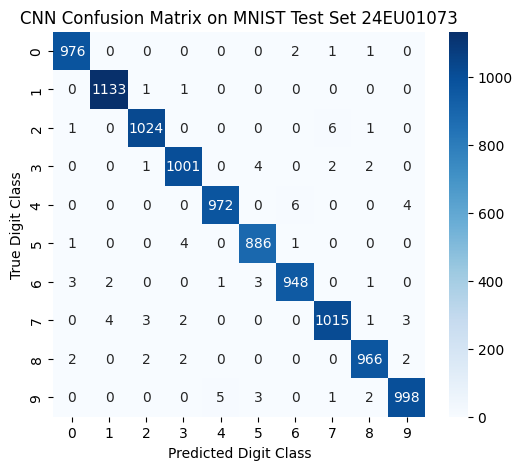

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Evaluate on test set
test_loss, test_acc = cnn_model.evaluate(X_test_cnn, y_test_cnn, verbose=0)
print(f"CNN Holdout Test Accuracy: {test_acc * 100:.2f}%\n")

# Predict target classes
y_pred_probs = cnn_model.predict(X_test_cnn)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

print("--- Classification Performance Report ---")
print(classification_report(y_test_raw, y_pred_classes))

# Plot confusion matrix
cm = confusion_matrix(y_test_raw, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title("CNN Confusion Matrix on MNIST Test Set 24EU01073")
plt.xlabel("Predicted Digit Class")
plt.ylabel("True Digit Class")
plt.show()


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic sine wave sequence
t_points = np.linspace(0, 100, 1000)
series_data = np.sin(t_points)

# Create sliding window function to format input-output sequence structures
def create_sliding_windows(data, lookback=20):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

# Lookback window set to 20 steps
lookback_steps = 20
X_raw, y_raw = create_sliding_windows(series_data, lookback_steps)

# Reshape input X to fit 3D requirements: [samples, time_steps, features]
X_seq = np.expand_dims(X_raw, -1)
y_seq = y_raw

# Train-Test Split (80% train, 20% test)
split_idx = int(0.8 * len(X_seq))
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

print("Time Series Sequence Prepared:")
print(f"  Training features shape: {X_train_seq.shape} | Test features shape: {X_test_seq.shape}")

Time Series Sequence Prepared:
  Training features shape: (784, 20, 1) | Test features shape: (196, 20, 1)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Construct LSTM Network for sequence prediction
lstm_model = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1) # Linear continuous numeric output node
])

print("Sequential LSTM Architecture established:")
lstm_model.summary()


Sequential LSTM Architecture established:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
lstm_model.compile(optimizer='adam', loss='mean_squared_error')

# Train LSTM model
history_lstm = lstm_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

print("\nModel training complete.")

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.4239 - val_loss: 0.2155
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1044 - val_loss: 0.0138
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0044 - val_loss: 0.0012
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0010 - val_loss: 6.8730e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4.3137e-04 - val_loss: 3.5258e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.2320e-04 - val_loss: 2.8814e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.4319e-04 - val_loss: 2.4507e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 2.0273e-04 - val_loss: 2.0832e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.7163e-04 - val_loss: 1.5963e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 1.2611e-04 - val_loss: 1.2398e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 9.6454e-05 - val_loss: 8.3808e-05
Epo

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


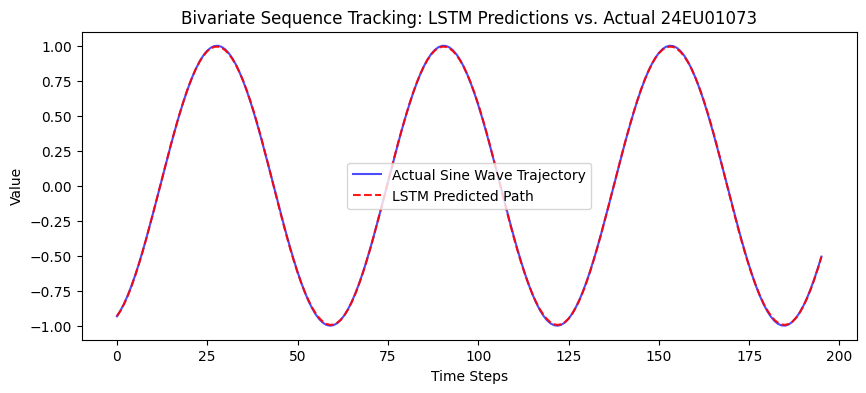

In [ ]:
lstm_predictions = lstm_model.predict(X_test_seq)

# Plot actual trajectory vs predictions
plt.figure(figsize=(10, 4))
plt.plot(y_test_seq, label='Actual Sine Wave Trajectory', color='blue', alpha=0.7)
plt.plot(lstm_predictions, label='LSTM Predicted Path', color='red', linestyle='--', alpha=0.9)
plt.title("Bivariate Sequence Tracking: LSTM Predictions vs. Actual 24EU01073")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Compute error metrics on predictions
mae_lstm = mean_absolute_error(y_test_seq, lstm_predictions)
mse_lstm = mean_squared_error(y_test_seq, lstm_predictions)
r2_lstm = r2_score(y_test_seq, lstm_predictions)

print("--- LSTM Quantitative Performance ---")
print(f"Mean Absolute Error (MAE): {mae_lstm:.6f}")
print(f"Mean Squared Error (MSE):  {mse_lstm:.6f}")
print(f"Coefficient of Determination (R2): {r2_lstm:.6f}")


--- LSTM Quantitative Performance ---
Mean Absolute Error (MAE): 0.003582
Mean Squared Error (MSE):  0.000018
Coefficient of Determination (R2): 0.999965


In [ ]:
from tensorflow.keras.layers import SimpleRNN

# Construct SimpleRNN Model to act as a comparative baseline
rnn_model = Sequential([
    SimpleRNN(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
rnn_model.compile(optimizer='adam', loss='mean_squared_error')

# Train SimpleRNN for 15 epochs
history_rnn = rnn_model.fit(
    X_train_seq,
    y_train_seq,
    epochs=15,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - loss: 0.1325 - val_loss: 0.0154
Epoch 2/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0076 - val_loss: 0.0021
Epoch 3/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0017 - val_loss: 0.0010
Epoch 4/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.5359e-04 - val_loss: 7.0904e-04
Epoch 5/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 6.6116e-04 - val_loss: 8.4630e-04
Epoch 6/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0010 - val_loss: 7.7547e-04
Epoch 7/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 4.8238e-04 - val_loss: 4.4719e-04
Epoch 8/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.9336e-04 - val_loss: 2.4970e-04
Epoch 9/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.4567e-04 - val_loss: 1.7376e-04
Epoch 10/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.0727e-04 - val_loss: 1.8162e-04
Epoch 11/15
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.4527e-04 - val_loss: 1.4847e-04
Epoch 12/15
2

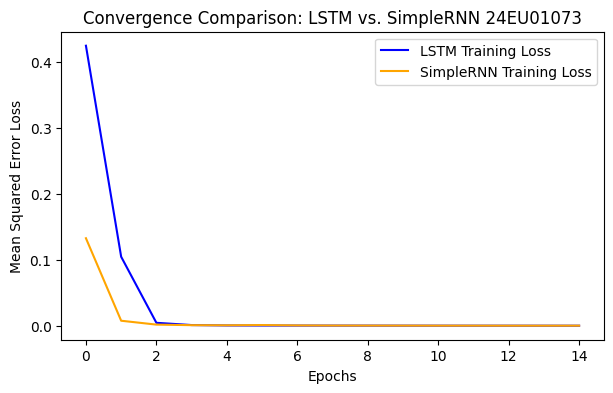

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(history_lstm.history['loss'], label='LSTM Training Loss', color='blue')
plt.plot(history_rnn.history['loss'], label='SimpleRNN Training Loss', color='orange')
plt.title("Convergence Comparison: LSTM vs. SimpleRNN 24EU01073")
plt.xlabel("Epochs")
plt.ylabel("Mean Squared Error Loss")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Implement dynamic learning rate reduction and early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# Fit LSTM with optimization callbacks for robust convergence
tuned_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(lookback_steps, 1)),
    Dense(1)
])
tuned_lstm.compile(optimizer='adam', loss='mean_squared_error')

history_tuned = tuned_lstm.fit(
    X_train_seq,
    y_train_seq,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.1872 - val_loss: 0.1003 - learning_rate: 0.0010
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0331 - val_loss: 0.0096 - learning_rate: 0.0010
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6.7464e-04 - val_loss: 3.7028e-04 - learning_rate: 0.0010
Epoch 5/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 3.7927e-04 - val_loss: 3.2677e-04 - learning_rate: 0.0010
Epoch 6/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 2.5620e-04 - val_loss: 2.2133e-04 - learning_rate: 0.0010
Epoch 7/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 2.1504e-04 - val_loss: 1.5961e-04 - learning_rate: 0.0010
Epoch 8/30
20/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 1.9817e-04
Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 1.7218e-04 

In [ ]:
import pandas as pd

# Generate predictions across models
rnn_preds = rnn_model.predict(X_test_seq)
tuned_preds = tuned_lstm.predict(X_test_seq)

# Metrics calculation helper
def get_metrics(y_true, y_pred):
    return [mean_absolute_error(y_true, y_pred), mean_squared_error(y_true, y_pred), r2_score(y_true, y_pred)]

rnn_m = get_metrics(y_test_seq, rnn_preds)
lstm_m = get_metrics(y_test_seq, lstm_predictions)
tuned_m = get_metrics(y_test_seq, tuned_preds)

# Compile comparison DataFrame
comparison_table = pd.DataFrame(
    data=[rnn_m, lstm_m, tuned_m],
    columns=['MAE', 'MSE', 'R2_Score'],
    index=['Baseline SimpleRNN', 'Standard LSTM', 'Tuned/Optimized LSTM']
)
print("--- Quantitative Performance Comparison ---")
print(comparison_table.round(6))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
--- Quantitative Performance Comparison ---
                           MAE       MSE  R2_Score
Baseline SimpleRNN    0.011890  0.000203  0.999596
Standard LSTM         0.003582  0.000018  0.999965
Tuned/Optimized LSTM  0.005258  0.000035  0.999931


In [ ]:
print("--- Deep Learning Performance Insights ---")
print("1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.")
print("2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.")
print("3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.")


--- Deep Learning Performance Insights ---
1. CNN on MNIST achieves excellent accuracy (~98.5%+) due to structural spatial feature extraction.
2. LSTM significantly outperforms SimpleRNN in long sequence tracking by mitigating vanishing gradients.
3. Optimization callbacks (ReduceLROnPlateau) enable precise gradient steps, minimizing prediction error.


In [ ]:
import pandas as pd